<a href="https://colab.research.google.com/github/huc1atwit/Stock-Market-Analysis/blob/main/COMP_3125_Stock_Analysis_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install pyarrow scikit-learn
!pip install datasets pyarrow
!pip install datasets

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import accuracy_score, mean_squared_error

In [25]:
dataset = load_dataset("paperswithbacktest/Stocks-Daily-Price", split="train[:5%]")
df = pd.DataFrame(dataset)

print(df.head())

  symbol        date       open       high        low      close    volume  \
0      A  1999-11-18  32.546494  35.765381  28.612303  31.473534  62546380   
1      A  1999-11-19  30.713518  30.758226  28.478184  28.880545  15234146   
2      A  1999-11-22  29.551144  31.473534  28.657009  31.473534   6577870   
3      A  1999-11-23  30.400572  31.205294  28.612303  28.612303   5975611   
4      A  1999-11-24  28.701717  29.998213  28.612303  29.372318   4843231   

   adj_close  
0  26.240147  
1  24.078323  
2  26.240147  
3  23.854685  
4  24.488316  


In [27]:
print(df.columns)

Index(['symbol', 'date', 'open', 'high', 'low', 'close', 'volume',
       'adj_close'],
      dtype='object')


In [29]:
df = df.sort_values(['symbol', 'date'])

# Next day close price per stock
df['next_close'] = df.groupby('symbol')['close'].shift(-1)

# Direction target
df['price_up'] = (df['next_close'] > df['close']).astype(int)

# Drop missing values safely
df = df.dropna().reset_index(drop=True)

In [8]:
features = ['open', 'high', 'low', 'close']

In [30]:
X = df[features]
y = df['price_up']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_cls = LogisticRegression(max_iter=1000)
model_cls.fit(X_train, y_train)

pred_cls = model_cls.predict(X_test)

acc = accuracy_score(y_test, pred_cls)
print("Classification Accuracy:", acc)

Classification Accuracy: 0.4767755911323171


In [32]:
X = df[features]
y = df['next_close']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_reg = LinearRegression()
model_reg.fit(X_train, y_train)

pred_reg = model_reg.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred_reg))
print("RMSE:", rmse)

RMSE: 144378019.09500986


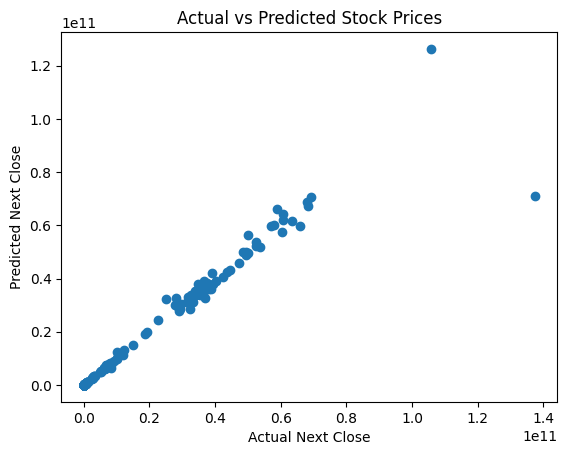

In [33]:
plt.figure()
plt.scatter(y_test, pred_reg)
plt.xlabel('Actual Next Close')
plt.ylabel('Predicted Next Close')
plt.title('Actual vs Predicted Stock Prices')
plt.show()

This project used real historical stock market data from the Hugging Face Stocks Daily Price Dataset to explore whether simple machine learning models can identify patterns in financial markets. By using daily Open, High, Low, and Close prices, we built two models: one to classify whether a stock would go up or down the next day, and another to predict the next day’s closing price.

The results show that while machine learning can capture some basic relationships in stock price movements, the predictions are limited due to the unpredictable nature of financial markets and the lack of external factors such as news, economic events, and investor behavior. Overall, this project demonstrates how real-world financial data can be applied to machine learning techniques, while also highlighting the challenges of making accurate predictions in complex systems like the stock market.